# Explore ML-ready distributions, correlation, and embeddings

**Goal.** Explore a bounded, deterministic payment world through computed tables and plots, including a clearly marked simulator-truth view when operational labels are not mature.

**Audience.** Data scientists and ML engineers exploring FraudTwin's generated features and model inputs.

**Prerequisites.** Python 3.12+, FraudTwin, and Polars. Optional plotting cells can install notebook packages.

**Source size.** 1,000 logical payments with a small fraud scenario enabled for the embedding demonstration; outputs are reproducible and temporary.

**Offline path.** Analysis runs without Kafka, databases, or cloud services.


## Optional notebook packages
Run this only for richer plots or t-SNE output.

```bash
!pip install matplotlib scikit-learn
```


## 1. Generate the source world


In [1]:
import json
from pathlib import Path
from tempfile import TemporaryDirectory

import polars as pl

import fraudtwin
from fraudtwin.config import SimulationRunConfig, load_config

root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "configs" / "minimal-v1.yaml").is_file()
)
base = load_config(root / "configs" / "minimal-v1.yaml")
values = base.model_dump(mode="python")
values["payments"]["daily_target"] = 100
values["simulation"]["duration_days"] = 10
values["population"].update(
    {
        "customers": 100,
        "accounts": 200,
        "cards": 200,
        "merchants": 30,
        "devices": 200,
        "pix_keys": 100,
    }
)
values["behavior"]["amount_max"] = 100
values["simulation"]["seed"] = 2501
values["fraud"]["enabled"] = True
values["fraud"]["target_rate"] = 0.05
config = SimulationRunConfig.model_validate(values)
data = fraudtwin.generate(config)
simulator_truth = {
    record.payment_id: int(record.fraud_truth) for record in data.behavior.fraud_records
}
simulator_fraud_count = sum(simulator_truth.values())
print("Source run")
print(f"  run_id: {data.run_id}")
print(f"  payments: {len(data.behavior.payments):,}")
print(f"  simulator fraud truth: {simulator_fraud_count:,}")
assert len(data.behavior.payments) >= 1_000

Source run
  run_id: RUN-f2bd687be19810c7
  payments: 1,092
  simulator fraud truth: 46


## 2. Analysis step


In [2]:
frame = data.require_dataset().frame
print({"rows": frame.height, "columns": frame.width})
assert frame.height > 0

{'rows': 1081, 'columns': 53}


## 3. Analysis step


In [3]:
numeric = [
    name
    for name, dtype in frame.schema.items()
    if dtype in (pl.Float64, pl.Float32, pl.Int64, pl.Int32)
]
print({"numeric_features": numeric[:12]})

{'numeric_features': ['amount', 'transaction_count_1m', 'transaction_count_5m', 'transaction_count_1h', 'transaction_count_24h', 'transaction_count_7d', 'transaction_count_30d', 'transaction_amount_1h', 'transaction_amount_24h', 'transaction_amount_7d', 'avg_transaction_amount_30d', 'max_transaction_amount_7d']}


## 4. Analysis step


In [4]:
missingness = frame.select([pl.col(name).is_null().mean().alias(name) for name in numeric[:8]])
missingness

amount,transaction_count_1m,transaction_count_5m,transaction_count_1h,transaction_count_24h,transaction_count_7d,transaction_count_30d,transaction_amount_1h
f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Analysis step


In [5]:
label_balance = (
    frame.group_by("label").len().sort("len", descending=True)
    if "label" in frame.columns
    else pl.DataFrame()
)
display(label_balance)

label,len
str,u32
null,1081


## 6. Analysis step


In [6]:
feature_summary = frame.select([pl.col(name).mean().alias(f"{name}_mean") for name in numeric[:6]])
feature_summary

amount_mean,transaction_count_1m_mean,transaction_count_5m_mean,transaction_count_1h_mean,transaction_count_24h_mean,transaction_count_7d_mean
f64,f64,f64,f64,f64,f64
39.853737,0.712303,0.718779,0.79741,1.882516,6.315449


## 7. Analysis step


In [7]:
correlation = frame.select(numeric[:6]).corr() if len(numeric) >= 2 else pl.DataFrame()
display(correlation)

amount,transaction_count_1m,transaction_count_5m,transaction_count_1h,transaction_count_24h,transaction_count_7d
f64,f64,f64,f64,f64,f64
1.0,-0.099808,-0.099875,-0.10012,-0.094979,-0.061106
-0.099808,1.0,0.999633,0.995041,0.828738,0.316516
-0.099875,0.999633,1.0,0.995481,0.828993,0.316903
-0.10012,0.995041,0.995481,1.0,0.834916,0.321428
-0.094979,0.828738,0.828993,0.834916,1.0,0.458411
-0.061106,0.316516,0.316903,0.321428,0.458411,1.0


## 8. Analysis step


In [8]:
time_splits = (
    frame.group_by("split").len().sort("split") if "split" in frame.columns else pl.DataFrame()
)
display(time_splits)

split,len
str,u32
"""test""",148
"""train""",794
"""validation""",139


## 9. Analysis step


In [9]:
embedding_input = frame.select(numeric[:6]).with_columns(
    [pl.col(name).cast(pl.Float64).fill_null(0.0).alias(name) for name in numeric[:6]]
)
try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    values = StandardScaler().fit_transform(embedding_input.to_numpy())
    sample_n = min(240, len(values))
    perplexity = min(30, max(5, sample_n // 10))
    embedding = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto",
        perplexity=perplexity,
        max_iter=350,
    ).fit_transform(values[:sample_n])
    print({"embedding_rows": sample_n, "method": "sklearn.TSNE", "shape": embedding.shape})
    assert embedding.shape == (sample_n, 2)
except ImportError:
    embedding = embedding_input.to_numpy()[: min(240, embedding_input.height)]
    print({"embedding_rows": len(embedding), "method": "scaled-feature fallback"})

{'embedding_rows': 240, 'method': 'sklearn.TSNE', 'shape': (240, 2)}


## Optional plot: inspect the embedding

Run this cell after the install cell to inspect the embedding. Mature operational labels are preferred; this bounded demo falls back to explicitly marked simulator truth because its generated labels are unresolved.


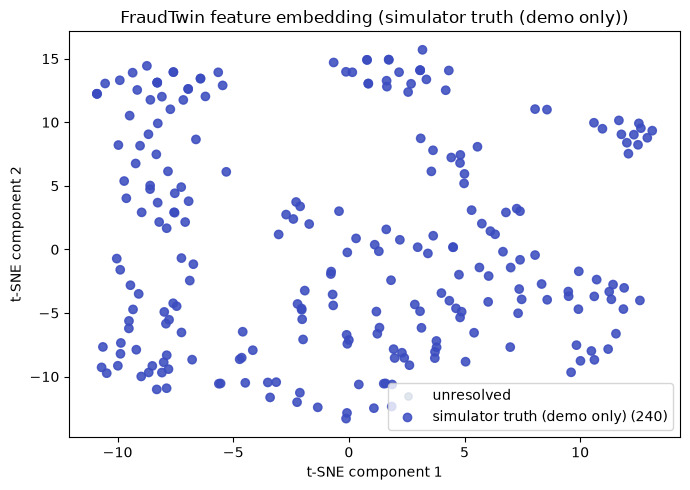

In [10]:
import matplotlib.pyplot as plt

operational_values = (
    frame.get_column("label").to_list()[: len(embedding)]
    if "label" in frame.columns
    else [None] * len(embedding)
)
if any(value is not None for value in operational_values):
    label_values = operational_values
    label_source = "mature operational labels"
elif simulator_fraud_count:
    label_values = [
        simulator_truth.get(payment_id, 0)
        for payment_id in frame["payment_id"].to_list()[: len(embedding)]
    ]
    label_source = "simulator truth (demo only)"
else:
    label_values = [None] * len(embedding)
    label_source = "labels unavailable"
known_positions = [index for index, value in enumerate(label_values) if value is not None]
fig, axis = plt.subplots(figsize=(7, 5))
axis.scatter(
    embedding[:, 0],
    embedding[:, 1],
    color="#cbd5e1",
    alpha=0.55,
    s=28,
    label="unresolved" if known_positions else "points",
)
if known_positions:
    label_codes = [
        1 if str(label_values[index]).lower() in {"1", "true", "fraud"} else 0
        for index in known_positions
    ]
    axis.scatter(
        embedding[known_positions, 0],
        embedding[known_positions, 1],
        c=label_codes,
        cmap="coolwarm",
        alpha=0.85,
        s=36,
        label=f"{label_source} ({len(known_positions):,})",
    )
    if len(set(label_codes)) > 1:
        fig.colorbar(axis.collections[-1], ax=axis, label="label code")
title = (
    f"FraudTwin feature embedding ({label_source})"
    if known_positions
    else "FraudTwin feature embedding (labels unavailable)"
)
axis.set(title=title, xlabel="t-SNE component 1", ylabel="t-SNE component 2")
axis.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

## 10. Analysis step


In [11]:
with TemporaryDirectory(prefix="fraudtwin-viz-27-") as tmp:
    report = Path(tmp) / "feature-summary.json"
    report.write_text(
        json.dumps({"numeric": numeric, "rows": frame.height}, default=str), encoding="utf-8"
    )
    print({"artifact": str(report), "bytes": report.stat().st_size})
    assert report.stat().st_size < 20_000

{'artifact': '/tmp/fraudtwin-viz-27-evt917tv/feature-summary.json', 'bytes': 731}
